# 01 — Ingestão e Limpeza de Dados

Este notebook carrega o dataset `flights.csv`, valida o schema, trata valores ausentes e salva os dados limpos em formato Parquet.

**Módulos utilizados:** `voos.ingestao`, `voos.limpeza`, `voos.utils`

In [1]:
import sys
import os

# Adicionar src/ ao path para importar o pacote voos
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))

from voos.ingestao import carregar_voos, validar_schema
from voos.limpeza import filtrar_voos_validos, salvar_parquet, tratar_valores_ausentes

## 1. Carregamento dos dados

In [2]:
CAMINHO_CSV = os.path.join(os.path.dirname(os.getcwd()), "data", "raw", "flights.csv")

df = carregar_voos(CAMINHO_CSV)
print(f"Dataset carregado: {len(df):,} linhas x {len(df.columns)} colunas")
print(f"\nSchema válido: {validar_schema(df)}")

Dataset carregado: 5,819,079 linhas x 31 colunas

Schema válido: True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype   
---  ------               -----   
 0   YEAR                 int16   
 1   MONTH                int8    
 2   DAY                  int8    
 3   DAY_OF_WEEK          int8    
 4   AIRLINE              category
 5   FLIGHT_NUMBER        int32   
 6   TAIL_NUMBER          object  
 7   ORIGIN_AIRPORT       category
 8   DESTINATION_AIRPORT  category
 9   SCHEDULED_DEPARTURE  int64   
 10  DEPARTURE_TIME       float64 
 11  DEPARTURE_DELAY      float64 
 12  TAXI_OUT             float64 
 13  WHEELS_OFF           float64 
 14  SCHEDULED_TIME       float64 
 15  ELAPSED_TIME         float64 
 16  AIR_TIME             float64 
 17  DISTANCE             int64   
 18  WHEELS_ON            float64 
 19  TAXI_IN              float64 
 20  SCHEDULED_ARRIVAL    int64   
 21  ARRIVAL_TIME         float64 
 22  ARRIVAL_DELAY        float64 
 23  DIVERTE

In [4]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


## 2. Análise de valores ausentes (antes da limpeza)

Valores ausentes por coluna (antes da limpeza):
CANCELLATION_REASON    5729195
WEATHER_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
AIRLINE_DELAY          4755640
SECURITY_DELAY         4755640
AIR_SYSTEM_DELAY       4755640
ELAPSED_TIME            105071
AIR_TIME                105071
ARRIVAL_DELAY           105071
ARRIVAL_TIME             92513
TAXI_IN                  92513
WHEELS_ON                92513
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6

Total de células nulas: 30,465,274


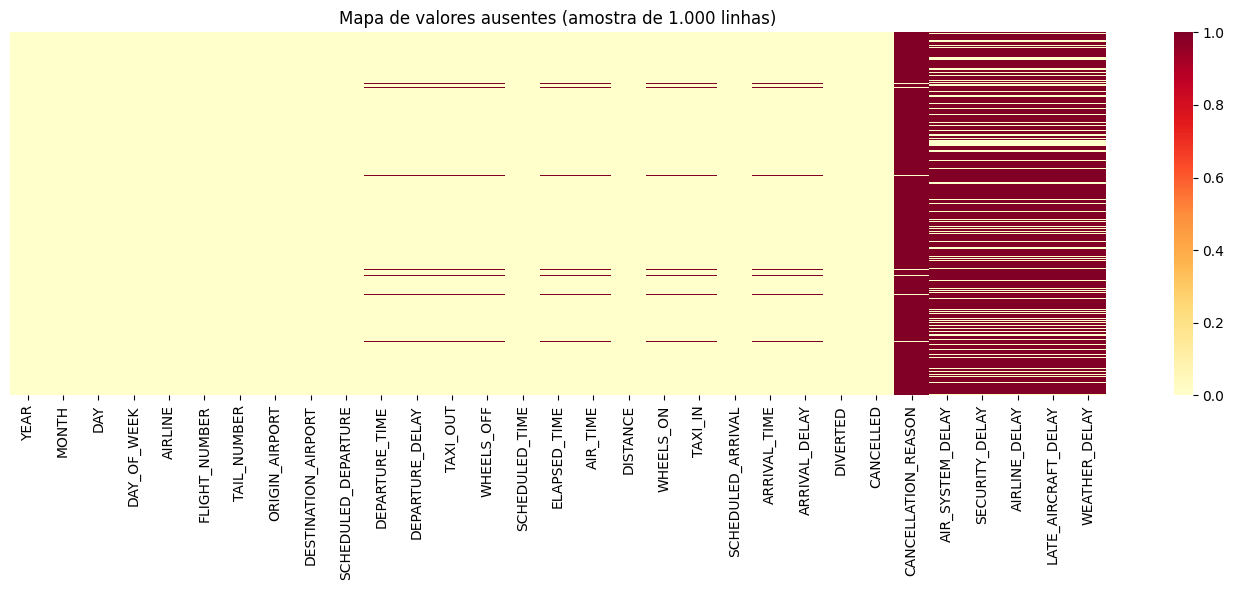

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem de nulos por coluna
nulos_antes = df.isna().sum()
nulos_antes = nulos_antes[nulos_antes > 0].sort_values(ascending=False)

print("Valores ausentes por coluna (antes da limpeza):")
print(nulos_antes.to_string())
print(f"\nTotal de células nulas: {df.isna().sum().sum():,}")

# Heatmap de valores ausentes (amostra para visualização)
fig, ax = plt.subplots(figsize=(14, 6))
amostra = df.sample(min(1000, len(df)), random_state=42)
sns.heatmap(amostra.isna(), cbar=True, yticklabels=False, cmap="YlOrRd", ax=ax)
ax.set_title("Mapa de valores ausentes (amostra de 1.000 linhas)")
plt.tight_layout()
plt.show()

## 3. Tratamento de valores ausentes e filtragem

**Estratégia de limpeza:**
- Colunas de delay breakdown (`AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, etc.): NaN para voos não cancelados é preenchido com 0 (indica que não houve atraso daquela categoria).
- Voos cancelados: mantêm NaN em colunas de tempo real (DEPARTURE_TIME, ARRIVAL_TIME) — é o comportamento esperado.
- Voos não cancelados sem `DEPARTURE_TIME`: dados corrompidos, removidos.

In [6]:
linhas_antes = len(df)

df = tratar_valores_ausentes(df)
df = filtrar_voos_validos(df)

linhas_depois = len(df)
print(f"Linhas antes: {linhas_antes:,}")
print(f"Linhas depois: {linhas_depois:,}")
print(f"Linhas removidas: {linhas_antes - linhas_depois:,} ({(linhas_antes - linhas_depois) / linhas_antes * 100:.2f}%)")

Linhas antes: 5,819,079
Linhas depois: 5,819,079
Linhas removidas: 0 (0.00%)


## 4. Valores ausentes após limpeza

In [7]:
nulos_depois = df.isna().sum()
nulos_depois = nulos_depois[nulos_depois > 0].sort_values(ascending=False)

print("Valores ausentes por coluna (após limpeza):")
if len(nulos_depois) > 0:
    print(nulos_depois.to_string())
else:
    print("Nenhum valor ausente restante (exceto colunas esperadas para cancelados).")
print(f"\nTotal de células nulas: {df.isna().sum().sum():,}")

Valores ausentes por coluna (após limpeza):
CANCELLATION_REASON    5729195
ARRIVAL_DELAY           105071
ELAPSED_TIME            105071
AIR_TIME                105071
TAXI_IN                  92513
WHEELS_ON                92513
ARRIVAL_TIME             92513
LATE_AIRCRAFT_DELAY      89884
AIRLINE_DELAY            89884
SECURITY_DELAY           89884
AIR_SYSTEM_DELAY         89884
WEATHER_DELAY            89884
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6

Total de células nulas: 7,136,494


## 5. Salvando dados limpos em Parquet

In [8]:
CAMINHO_PARQUET = os.path.join(os.path.dirname(os.getcwd()), "data", "processed", "voos_limpos.parquet")

salvar_parquet(df, CAMINHO_PARQUET)
print(f"Dados limpos salvos em: {CAMINHO_PARQUET}")
print(f"Shape final: {df.shape}")

Dados limpos salvos em: /Users/nsx001191/Documents/fiap/fiap-tcf-3/data/processed/voos_limpos.parquet
Shape final: (5819079, 31)
